**Description**
**action**: [K1_t, K2_t, K3_t, K4_t, K5_t, K6_t, d_t] (7D), K1-K6 are stiffness, d is damping factor, take the damping matrix to be [B1_t, B2_t, B3_t, B4_t, B5_t, B6_t] = d_t * sqrt(K_t)
**state**: [e_t, pd_t] (6D) tracking error e, desired position at every time step pd_t, the final goal is to reach the desired position-the hole and insert the peg in a fixed hole, which is located at [0, -0.7, 0.0]

**mission**: use adversial inverse reinforcement learning to train the reward function of this peg in hole task.

since we are using position control robot, we should use admittance control. The modified desired position pd_new_t = pd_t + e_t, and the desired orientation should stay the same, which means Rd_t is a constant. With these calculated, we can get the desired joint position q_d_t at every time step, and control the robot to reach the next state.

the reasons for choosing these state variables are:
- pd_t stands for the ideal trajectory
- e_t stands for the admittance dynamics, M * e'' + B * e' + K * e = F_external
by combining them, we can get the proper infomations for the robot to interact with the environment

and for the actions, K should be a 6 * 6 matrix, for simplicity, we consider it a diagonal matrix made of 6 components, so is B. The mass matrix is diagonal as well, and is given in advance.

Adversial Inverse Reinforcement Learning: 

Input expert demo trajectory
• collect expert demostration trajectory \tau_i^D (provided in mujoco_wrappers/data/expert_demostration.pkl)

Initialize
• randomly initialize policy $ \pi (s,a) $ and reward function $ r_\theta(s,a) $ 。

Training Loop（Iterations $ k = 1 \dots K $ ）
• Step A： Sample the trajectory
 collect trajectory $ \tau_i $ under policy $ \pi (s,a) $ 

• Step B：Update reward function $ r_\theta(s,a) $ by minimizing Loss function $ L(\theta) $

Define discriminator：
$$
D_\theta(o,a) = \frac{\exp(r_\theta(o,a))}{\exp(r_\theta(o,a)) + \pi(a|o)}
$$
minimizing Loss function：
$$
L(\theta) = \sum_{t=0}^{T} \left[ -\mathbb{E}{D}[\log D_{\theta} (o_t,a_t)] - \mathbb{E}{\pi_t}[1 - \log D_{\theta} (o_t,a_t)] \right]
$$
to distinguish from expert trajectory to the policy
 
• Step C：evaluate trajectory reward 

use the updated reward function $ r_\theta'(s,a) $ to evaluate the trajectory

• Setp D：update the policy

use PPO to update policy $ \pi (s,a) $ by maximazing $ r_\theta'(s,a) $

Output
• learned gain scheduling policy $ \pi (s,a) $ and corresponding reward function $ r_\theta'(s,a) $


Under our circumstances, you need to finish writing the AIRL Algorithm, and I will provide the expert data
Notice that the reward in environment file mujoco_wrappers/env/peg_in_hole_env.py is set to be 0,which is to use the trained raward function $ r_\theta'(s,a) $ update policy.

In [8]:
"""
AIRL (Adversarial Inverse Reinforcement Learning) Trainer for Variable Admittance Control
Peg-in-Hole Task Implementation

Variable Admittance Control:
- State Space: [e_t, pd_t] (6D) where e_t is tracking error, pd_t is desired position  
- Action Space: [K1, K2, K3, K4, K5, K6, d_t] (7D) impedance parameters
- Modified desired position: pd_new_t = pd_t + e_t
- Admittance dynamics: M * e'' + B * e' + K * e = F_external
- Damping matrix: B = d_t * sqrt(K)
"""

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import pickle
import matplotlib.pyplot as plt
from collections import deque
import random
from typing import Dict, List, Tuple, Optional
import logging

current_dir = os.getcwd()

if 'mujoco_wrappers' in current_dir:
    if not current_dir.endswith('mujoco_wrappers'):
        # Navigate to root
        root_path = current_dir.split('mujoco_wrappers')[0] + 'mujoco_wrappers'
        os.chdir(root_path)
        print(f"Changed working directory to: {os.getcwd()}")
else:
    print("Warning: Could not find mujoco_wrappers in current path")

# Add path for environment
sys.path.append(os.getcwd())

from envs.peg_in_hole_env import PegInHoleEnv

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Working directory: {os.getcwd()}")

Using device: cuda
Working directory: /home/auksphere/robotics/mujoco_wrappers


In [9]:
# Neural Network Components for AIRL

class RewardNetwork(nn.Module):
    """AIRL reward approximator g_θ(s)"""
    def __init__(self, state_dim, hidden_dim=256):
        super(RewardNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
)
    
    def forward(self, state):
        return self.network(state)

class ValueNetwork(nn.Module):
    """AIRL value function h_φ(s)"""
    def __init__(self, state_dim, hidden_dim=256):
        super(ValueNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
)
    
    def forward(self, state):
        return self.network(state)

class AIRLDiscriminator(nn.Module):
    """AIRL discriminator D_θ,φ(s,a,s')"""
    def __init__(self, state_dim, action_dim, hidden_dim=256, gamma=0.99):
        super(AIRLDiscriminator, self).__init__()
        self.reward_net = RewardNetwork(state_dim, hidden_dim)
        self.value_net = ValueNetwork(state_dim, hidden_dim)
        self.gamma = gamma
        
    def forward(self, state, action, next_state, log_prob):
        """Compute discriminator output"""
        reward = self.reward_net(state)
        value_curr = self.value_net(state)
        value_next = self.value_net(next_state)
        
        f = reward + self.gamma * value_next - value_curr
        f = torch.clamp(f, min=-10, max=10)
        
        if log_prob.dim() == 1:
            log_prob = log_prob.unsqueeze(-1)
        
        # D = 1 / (1 + exp(log_prob - f))
        discriminator_output = torch.sigmoid(f - log_prob)
        discriminator_output = torch.clamp(discriminator_output, min=1e-8, max=1-1e-8)
        
        return discriminator_output, reward
    
    def get_reward(self, state, action, next_state, log_prob):
        """Extract reward for RL training"""
        with torch.no_grad():
            disc_output, _ = self.forward(state, action, next_state, log_prob)
            disc_output = torch.clamp(disc_output, min=1e-8, max=1-1e-8)
            reward = torch.log(disc_output) - torch.log(1 - disc_output)
            reward = torch.clamp(reward, min=-10, max=10)
        return reward.squeeze()

In [10]:
class VariableImpedancePolicy(nn.Module):
    """Policy network for impedance learning"""
    def __init__(self, state_dim=6, action_dim=7, hidden_dim=128):
        super(VariableImpedancePolicy, self).__init__()
        
        self.error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
)
        
        self.position_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
)
        
        self.shared_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
)
        
        self.stiffness_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 12)
)
        
        self.damping_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 2)
)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.8)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        with torch.no_grad():
            self.stiffness_branch[-1].weight.data *= 0.5
            self.stiffness_branch[-1].bias.data[:6] = 0.3
            self.stiffness_branch[-1].bias.data[6:] = -0.7
            
            self.damping_branch[-1].weight.data *= 0.7
            self.damping_branch[-1].bias.data[0] = 0.2
            self.damping_branch[-1].bias.data[1] = -0.5
    
    def forward(self, state):
        if torch.isnan(state).any():
            state = torch.where(torch.isnan(state), torch.zeros_like(state), state)
        
        tracking_error = state[:, :3]
        desired_position = state[:, 3:]
        
        error_features = self.error_encoder(tracking_error)
        position_features = self.position_encoder(desired_position)
        
        combined_features = torch.cat([error_features, position_features], dim=-1)
        shared_features = self.shared_net(combined_features)
        
        stiffness_output = self.stiffness_branch(shared_features)
        damping_output = self.damping_branch(shared_features)
        
        stiffness_mean = stiffness_output[:, :6]
        stiffness_log_std = stiffness_output[:, 6:]
        damping_mean = damping_output[:, 0:1]
        damping_log_std = damping_output[:, 1:2]
        
        mean = torch.cat([stiffness_mean, damping_mean], dim=-1)
        log_std = torch.cat([stiffness_log_std, damping_log_std], dim=-1)
        
        mean = torch.clamp(mean, min=-2.5, max=2.5)
        log_std = torch.clamp(log_std, min=-1.0, max=0.7)
        
        return mean, log_std
    
    def sample_action(self, state):
        """Sample action with tanh squashing to [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.03, max=1.0)
        
        try:
            dist = Normal(mean, std)
            z = dist.rsample()
            action = torch.tanh(z)
            
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            log_prob = torch.clamp(log_prob, min=-12, max=12)
            
            return action, log_prob
        except Exception:
            action = torch.tanh(mean)
            log_prob = torch.zeros(action.shape[0], device=action.device)
            return action, log_prob
    
    def evaluate_action(self, state, action):
        """Evaluate log probability of given action in [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.03, max=1.0)
        
        action = torch.clamp(action, min=-0.999, max=0.999)
        z = 0.5 * torch.log((1 + action) / (1 - action + 1e-8))
        
        try:
            dist = Normal(mean, std)
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            return torch.clamp(log_prob, min=-12, max=12)
        except Exception:
            return torch.zeros(action.shape[0], device=action.device)
    
    def get_deterministic_action(self, state):
        """Deterministic action for evaluation"""
        mean, _ = self.forward(state)
        return torch.tanh(mean)

In [11]:
class ExpertDataLoader:
    """
    Load and process expert demonstration data
    Format: [e_t(3), pd_t(3), action] where:
    - e_t: tracking error (3D position) 
    - pd_t: desired position (3D position)
    - action: [K1, K2, K3, K4, K5, K6, damping_ratio] impedance parameters
    """
    def __init__(self, expert_data_path):
        self.expert_data_path = expert_data_path
        self.trajectories = []
        self.obs_stats = None
        self.act_stats = None
        self.load_expert_data()
    
    def load_expert_data(self):
        """Load expert trajectories from pickle file"""
        try:
            with open(self.expert_data_path, 'rb') as f:
                data = pickle.load(f)
            
            print(f"Loaded expert data from {self.expert_data_path}")
            
            # Expected format from vac_expert_generator.py merge
            if isinstance(data, dict) and 'observations' in data and 'actions' in data:
                observations = np.array(data['observations'])  # Shape: (N, 6) [e_t(3), pd_t(3)]
                actions = np.array(data['actions'])           # Shape: (N, 7) [K1-K6, damping]
                
                print(f"✓ Data format validated")
                print(f"✓ Observations: {observations.shape} - {data['metadata']['observation_description']}")
                print(f"✓ Actions: {actions.shape} - {data['metadata']['action_description']}")
                print(f"✓ Total samples: {len(observations)}")
                print(f"✓ Trajectories: {data['metadata']['num_trajectories']}")
                
                # Calculate statistics for normalization
                self.obs_stats = {
                    'mean': observations.mean(axis=0),
                    'std': observations.std(axis=0),
                    'min': observations.min(axis=0),
                    'max': observations.max(axis=0)
                }
                
                self.act_stats = {
                    'mean': actions.mean(axis=0),
                    'std': actions.std(axis=0),
                    'min': actions.min(axis=0),
                    'max': actions.max(axis=0)
                }
                
                # Split into trajectories based on metadata
                trajectory_indices = data['metadata']['trajectory_indices']
                num_trajectories = data['metadata']['num_trajectories']
                
                # Estimate trajectory length (assuming roughly equal lengths)
                avg_traj_len = len(observations) // num_trajectories
                
                # Create trajectories (simplified - could use actual trajectory boundaries)
                for i in range(num_trajectories):
                    start_idx = i * avg_traj_len
                    end_idx = min((i + 1) * avg_traj_len, len(observations))
                    
                    if start_idx < len(observations):
                        traj_obs = observations[start_idx:end_idx]
                        traj_acts = actions[start_idx:end_idx]
                        
                        # Create next states (shifted by 1)
                        if len(traj_obs) > 1:
                            next_states = traj_obs[1:]
                            traj_obs = traj_obs[:-1] 
                            traj_acts = traj_acts[:-1]
                        else:
                            next_states = traj_obs.copy()
                        
                        trajectory = {
                            'states': traj_obs,
                            'actions': traj_acts,
                            'next_states': next_states
                        }
                        self.trajectories.append(trajectory)
                
                print(f"✓ Created {len(self.trajectories)} trajectory segments")
                
                # Print data ranges for verification
                print(f"\nData Ranges:")
                print(f"  Tracking Error (e_t): X[{observations[:, 0].min():.3f}, {observations[:, 0].max():.3f}] Y[{observations[:, 1].min():.3f}, {observations[:, 1].max():.3f}] Z[{observations[:, 2].min():.3f}, {observations[:, 2].max():.3f}]")
                print(f"  Desired Pos (pd_t):   X[{observations[:, 3].min():.3f}, {observations[:, 3].max():.3f}] Y[{observations[:, 4].min():.3f}, {observations[:, 4].max():.3f}] Z[{observations[:, 5].min():.3f}, {observations[:, 5].max():.3f}]")
                print(f"  Stiffness K1-K3:     [{actions[:, :3].min():.0f}, {actions[:, :3].max():.0f}] N/m")
                print(f"  Stiffness K4-K6:     [{actions[:, 3:6].min():.0f}, {actions[:, 3:6].max():.0f}] Nm/rad")
                print(f"  Damping ratio:       [{actions[:, 6].min():.2f}, {actions[:, 6].max():.2f}]")
                
                # Analyze damping coefficient distribution
                damping_data = actions[:, 6]
                print(f"\nDamping coefficient analysis:")
                print(f"  Mean: {damping_data.mean():.3f}")
                print(f"  Std dev: {damping_data.std():.3f}")
                print(f"  Coefficient of variation: {damping_data.std()/damping_data.mean():.3f}")
                
            else:
                print(f"✗ Unexpected data format: {type(data)}")
                if hasattr(data, 'keys'):
                    print(f"  Available keys: {data.keys()}")
            
        except FileNotFoundError:
            print(f"✗ Expert data file {self.expert_data_path} not found!")
            print("Please ensure expert_demonstration.pkl exists in data/ directory")
        except Exception as e:
            print(f"✗ Error loading expert data: {e}")
            import traceback
            traceback.print_exc()
    
    def normalize_observations(self, obs):
        """Normalize observations for training stability"""
        if self.obs_stats is None:
            return obs
        
        # Normalize to [-1, 1] range, handle zero range to avoid division by zero
        obs_range = self.obs_stats['max'] - self.obs_stats['min']
        obs_range = np.where(obs_range == 0, 1.0, obs_range)  # Replace 0 with 1 to avoid division by zero
        obs_norm = (obs - self.obs_stats['min']) / obs_range * 2 - 1
        return obs_norm
    
    def normalize_actions(self, actions):
        """
        Enhanced action normalization with better handling for both stiffness and damping
        - Stiffness K1-K6: logarithmic normalization to enhance sensitivity to variations, mapped to [-1, 1]
        - Damping coefficient: square root transform to enhance numerical range, mapped to [-1, 1]
        """
        if self.act_stats is None:
            return actions
        
        actions_norm = actions.copy()
        
        for i in range(actions.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                # No variation in this dimension -> map to 0 in [-1, 1] space
                actions_norm[:, i] = 0.0
                continue
            
            if i < 6:  # Stiffness K1-K6 - use logarithmic normalization for better sensitivity
                epsilon = 1e-3
                actions_safe = np.maximum(actions[:, i], epsilon)
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_actions = np.log(actions_safe)
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    # Map log-scaled values to [-1, 1]
                    actions_norm[:, i] = (log_actions - log_min) / log_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
            else:  # Damping coefficient - square root transform
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_actions = np.sqrt(np.clip(actions[:, i], act_min_safe, act_max_safe))
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    # Map sqrt-scaled values到[-1, 1]
                    actions_norm[:, i] = (sqrt_actions - sqrt_min) / sqrt_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
        
        return actions_norm
    
    def denormalize_actions(self, actions_norm):
        """
        Enhanced action denormalization: inverse of normalize_actions
        """
        if self.act_stats is None:
            return actions_norm
        
        actions = actions_norm.copy()
        
        for i in range(actions_norm.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                actions[:, i] = act_min
                continue
            
            if i < 6:  # Stiffness K1-K6 - inverse logarithmic transform from [-1, 1]
                epsilon = 1e-3
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    log_value = t * log_range + log_min
                    actions[:, i] = np.exp(log_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
            else:  # Damping coefficient - square root inverse transform from [-1, 1]
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    sqrt_value = t * sqrt_range + sqrt_min
                    actions[:, i] = np.square(sqrt_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
        
        return actions
    
    def get_expert_transitions(self, batch_size=256):
        """Get random batch of expert state-action transitions"""
        if not self.trajectories:
            return None, None, None, None
        
        states, actions, next_states = [], [], []
        
        for _ in range(batch_size):
            # Sample random trajectory
            traj = random.choice(self.trajectories)
            
            # Sample random transition from trajectory
            if len(traj['states']) > 0:
                idx = random.randint(0, len(traj['states']) - 1)
                states.append(traj['states'][idx])
                actions.append(traj['actions'][idx])
                
                if idx < len(traj['next_states']):
                    next_states.append(traj['next_states'][idx])
                else:
                    next_states.append(traj['states'][idx])  # Use same state if at end
        
        states = np.array(states)
        actions = np.array(actions)
        next_states = np.array(next_states)
        
        # Normalize data
        states = self.normalize_observations(states)
        actions = self.normalize_actions(actions)
        next_states = self.normalize_observations(next_states)
        
        return states, actions, next_states, np.ones(batch_size)  # expert labels = 1

class ReplayBuffer:
    """Experience replay buffer for policy trajectories"""
    def __init__(self, max_size=100000):
        self.max_size = max_size
        self.buffer = deque(maxlen=max_size)
    
    def add(self, state, action, next_state, reward, done, log_prob):
        self.buffer.append((state, action, next_state, reward, done, log_prob))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        states, actions, next_states, rewards, dones, log_probs = zip(*batch)
        
        return (np.array(states), np.array(actions), np.array(next_states),
                np.array(rewards), np.array(dones), np.array(log_probs))
    
    def __len__(self):
        return len(self.buffer)

In [ ]:
# AIRL Algorithm Implementation
class AIRLTrainer:
    """
    Adversarial Inverse Reinforcement Learning (AIRL) Trainer
    """
    def __init__(self, env, expert_data_path, lr_policy=5e-4, lr_discriminator=5e-5):
        self.env = env
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy = VariableImpedancePolicy(hidden_dim=128).to(self.device)
        self.discriminator = AIRLDiscriminator(6, 7, hidden_dim=128).to(self.device)
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=lr_policy)
        self.discriminator_optimizer = optim.Adam(self.discriminator.parameters(), lr=lr_discriminator)
        self.policy_scheduler = optim.lr_scheduler.StepLR(self.policy_optimizer, step_size=25, gamma=0.8)
        self.disc_scheduler = optim.lr_scheduler.StepLR(self.discriminator_optimizer, step_size=30, gamma=0.9)
        self.expert_loader = ExpertDataLoader(expert_data_path)
        self.replay_buffer = ReplayBuffer(max_size=50000)
        self.metrics = {
            'discriminator_loss': [], 'policy_loss': [], 'airl_rewards': [],
            'discriminator_accuracy': [], 'episode_airl_rewards': [],
            'expert_disc_output': [], 'policy_disc_output': [], 'reward_estimates': []
        }
        self.current_iteration = 0
        self.best_airl_reward = -float('inf')
        self.best_score = -float('inf')

    def sample_trajectories(self, num_episodes=5):
        print(f"Sampling trajectories ({num_episodes} episodes)")
        self.policy.eval()
        collected_episodes = 0
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            episode_airl_reward = 0
            trajectory_states, trajectory_actions, trajectory_next_states, trajectory_log_probs = [], [], [], []
            max_steps = 200
            for step in range(max_steps):
                state_norm = self.expert_loader.normalize_observations(state.reshape(1, -1))[0]
                state_tensor = torch.FloatTensor(state_norm).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    action_norm, log_prob = self.policy.sample_action(state_tensor)
                    action_norm = action_norm.cpu().numpy()[0]
                    log_prob = log_prob.cpu().numpy()[0]
                action_denorm = self.expert_loader.denormalize_actions(action_norm.reshape(1, -1))[0]
                next_state, _, done, truncated, info = self.env.step(action_denorm)
                next_state_norm = self.expert_loader.normalize_observations(next_state.reshape(1, -1))[0]
                trajectory_states.append(state_norm)
                trajectory_actions.append(action_norm)
                trajectory_next_states.append(next_state_norm)
                trajectory_log_probs.append(log_prob)
                state = next_state
                if done or truncated:
                    break
            if len(trajectory_states) > 0:
                with torch.no_grad():
                    states_tensor = torch.FloatTensor(trajectory_states).to(self.device)
                    actions_tensor = torch.FloatTensor(trajectory_actions).to(self.device)
                    next_states_tensor = torch.FloatTensor(trajectory_next_states).to(self.device)
                    log_probs_tensor = torch.FloatTensor(trajectory_log_probs).to(self.device)
                    airl_rewards = self.discriminator.get_reward(states_tensor, actions_tensor, next_states_tensor, log_probs_tensor)
                    airl_rewards_np = airl_rewards.cpu().numpy()
                for i in range(len(trajectory_states)):
                    airl_reward = airl_rewards_np[i]
                    done_flag = (i == len(trajectory_states) - 1)
                    self.replay_buffer.add(trajectory_states[i], trajectory_actions[i], trajectory_next_states[i], airl_reward, done_flag, trajectory_log_probs[i])
                    episode_airl_reward += airl_reward
            self.metrics['episode_airl_rewards'].append(episode_airl_reward)
            if episode_airl_reward > self.best_airl_reward:
                self.best_airl_reward = episode_airl_reward
            collected_episodes += 1
        recent_airl_reward = np.mean(self.metrics['episode_airl_rewards'][-collected_episodes:])
        print(f"Collected {collected_episodes} trajectories")
        print(f"Avg AIRL reward: {recent_airl_reward:.4f} (best: {self.best_airl_reward:.4f})")
        self.policy.train()

    def update_reward(self, num_updates=2):
        print(f"Updating reward function ({num_updates} updates)")
        if len(self.replay_buffer) < 256:
            print("Insufficient data, skipping discriminator update")
            return 0.0, 0.5
        total_loss = 0.0
        total_accuracy = 0.0
        for update_idx in range(num_updates):
            batch_size = 128

            expert_states, expert_actions, expert_next_states, _ = self.expert_loader.get_expert_transitions(batch_size)
            
            policy_states, policy_actions, policy_next_states, _, _, policy_log_probs = self.replay_buffer.sample(batch_size)
            expert_states = torch.FloatTensor(expert_states).to(self.device)
            expert_actions = torch.FloatTensor(expert_actions).to(self.device)
            expert_next_states = torch.FloatTensor(expert_next_states).to(self.device)

            policy_states = torch.FloatTensor(policy_states).to(self.device)
            policy_actions = torch.FloatTensor(policy_actions).to(self.device)
            policy_next_states = torch.FloatTensor(policy_next_states).to(self.device)

            policy_log_probs = torch.FloatTensor(policy_log_probs).to(self.device)
            expert_log_probs = self.policy.evaluate_action(expert_states, expert_actions)
            expert_disc_output, expert_rewards = self.discriminator(expert_states, expert_actions, expert_next_states, expert_log_probs)
            policy_disc_output, policy_rewards = self.discriminator(policy_states, policy_actions, policy_next_states, policy_log_probs)
            
            expert_loss = -torch.log(expert_disc_output * 0.98 + 0.02).mean()
            policy_loss = -torch.log((1 - policy_disc_output) * 0.98 + 0.02).mean()
            discriminator_loss = expert_loss + policy_loss
            
            self.discriminator_optimizer.zero_grad()
            discriminator_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.discriminator.parameters(), 1.0)
            
            self.discriminator_optimizer.step()
            expert_correct = (expert_disc_output > 0.5).float().sum()
            policy_correct = (policy_disc_output <= 0.5).float().sum()
            
            accuracy = (expert_correct + policy_correct) / (2 * batch_size)
            total_loss += discriminator_loss.item()
            total_accuracy += accuracy.item()
            
            self.metrics['expert_disc_output'].append(expert_disc_output.mean().item())
            self.metrics['policy_disc_output'].append(policy_disc_output.mean().item())
        
        avg_loss = total_loss / num_updates
        avg_accuracy = total_accuracy / num_updates
        print(f"Discriminator updated: loss={avg_loss:.4f}, accuracy={avg_accuracy:.3f} (target: 0.5)")
        return avg_loss, avg_accuracy

    def evaluate_trajectory_reward(self, sample_size=64):
        if len(self.replay_buffer) < sample_size:
            return 0.0
        
        states, actions, next_states, stored_rewards, _, _ = self.replay_buffer.sample(sample_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.FloatTensor(actions).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        
        with torch.no_grad():
            log_probs = self.policy.evaluate_action(states, actions)
            airl_rewards = self.discriminator.get_reward(states, actions, next_states, log_probs)
            current_airl_avg = airl_rewards.mean().item()
            stored_airl_avg = np.mean(stored_rewards)
            self.metrics['reward_estimates'].append(current_airl_avg)
        print(f"AIRL rewards: current={current_airl_avg:.4f}, stored={stored_airl_avg:.4f}")
        return current_airl_avg

    def update_policy(self, num_updates=12):
        print(f"Updating policy using AIRL rewards ({num_updates} updates)")
        if len(self.replay_buffer) < 256:
            print("Insufficient data, skipping policy update")
            return 0.0
        
        total_policy_loss = 0.0
        bc_weight = 0.6
        var_target = 0.5
        var_reg_weight = 0.5

        for update_idx in range(num_updates):
            batch_size = 256
            states, actions, next_states, airl_rewards, dones, old_log_probs = self.replay_buffer.sample(batch_size)
            states = torch.FloatTensor(states).to(self.device)
            actions = torch.FloatTensor(actions).to(self.device)
            
            next_states = torch.FloatTensor(next_states).to(self.device)
            airl_rewards = torch.FloatTensor(airl_rewards).to(self.device)
            old_log_probs = torch.FloatTensor(old_log_probs).to(self.device)
            new_log_probs = self.policy.evaluate_action(states, actions)
            
            normalized_rewards = (airl_rewards - airl_rewards.mean()) / (airl_rewards.std() + 1e-8)
            ratio = torch.exp(new_log_probs - old_log_probs)
            clipped_ratio = torch.clamp(ratio, 0.5, 1.5)
            
            surr1 = ratio * normalized_rewards
            surr2 = clipped_ratio * normalized_rewards
            
            policy_loss = -torch.mean(torch.min(surr1, surr2))
            action_variance = actions.var(dim=0)
            
            stiffness_var = action_variance[:6].mean()
            damping_var = action_variance[6]
            stiffness_var_deficit = torch.clamp(var_target - stiffness_var, min=0.0)
            damping_var_deficit = torch.clamp(var_target - damping_var, min=0.0)
            
            stiffness_reg = var_reg_weight * stiffness_var_deficit
            damping_reg = var_reg_weight * damping_var_deficit
            _, log_std = self.policy.forward(states)

            entropy_bonus = 0.5 * log_std.sum(dim=-1).mean()

            expert_batch_size = 64
            expert_states, expert_actions, _, _ = self.expert_loader.get_expert_transitions(expert_batch_size)
            
            expert_states = torch.FloatTensor(expert_states).to(self.device)
            expert_actions = torch.FloatTensor(expert_actions).to(self.device)

            with torch.no_grad():
                target_actions = expert_actions
            pred_actions, _ = self.policy.sample_action(expert_states)

            bc_loss = torch.nn.functional.mse_loss(pred_actions, target_actions)
            total_loss = policy_loss + stiffness_reg + damping_reg - entropy_bonus + bc_weight * bc_loss
            self.policy_optimizer.zero_grad()
            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
            self.policy_optimizer.step()
            total_policy_loss += total_loss.item()

        avg_policy_loss = total_policy_loss / num_updates
        recent_airl_rewards = self.metrics['episode_airl_rewards'][-10:] if self.metrics['episode_airl_rewards'] else [0]
        current_avg_airl = np.mean(recent_airl_rewards)
        self.metrics['airl_rewards'].append(current_avg_airl)
        print(f"    Policy updated: loss={avg_policy_loss:.4f}, AIRL reward={current_avg_airl:.4f}")
        
        return avg_policy_loss

    def train(self, num_iterations=50, best_save_path=None):
        print(f"\n{'='*60}")
        print("Improved AIRL Training Started")
        print("Focus: Better training balance for Nash equilibrium")
        print(f"Training iterations: {num_iterations}")
        print(f"{'='*60}")
        print("\nInitialization:")
        print("  Collecting initial trajectories...")
        self.sample_trajectories(15)
        print(f"  Initial data collected: {len(self.replay_buffer)} transitions")

        for iteration in range(num_iterations):
            self.current_iteration = iteration
            print(f"\n--- AIRL Iteration {iteration + 1}/{num_iterations} ---")
            self.sample_trajectories(5)
            recent_acc = self.metrics['discriminator_accuracy'][-5:] if len(self.metrics['discriminator_accuracy']) >= 5 else [0.6]
            avg_acc = np.mean(recent_acc)
            nash_distance = abs(avg_acc - 0.5)

            if nash_distance > 0.3:
                if avg_acc > 0.8:
                    disc_updates = 1
                    policy_updates = 10
                    strategy = "strong discriminator suppression"

                elif avg_acc < 0.2:
                    disc_updates = 1
                    policy_updates = 10
                    strategy = "weak discriminator boost"

                else:
                    disc_updates = 2
                    policy_updates = 12
                    strategy = "balanced approach (far from Nash)"
            else:
                disc_updates = 1
                policy_updates = 10
                strategy = "Nash equilibrium maintenance"

            if iteration > 40 and nash_distance < 0.15:
                disc_updates = 0
                strategy += " + late-stage disc freeze"
            print(f"  Strategy: {strategy} (disc accuracy: {avg_acc:.3f}, Nash distance: {nash_distance:.3f})")
            disc_loss, disc_acc = self.update_reward(disc_updates) if disc_updates > 0 else (0.0, avg_acc)
            self.metrics['discriminator_loss'].append(disc_loss)
            self.metrics['discriminator_accuracy'].append(disc_acc)
            avg_airl_reward = self.evaluate_trajectory_reward()
            policy_loss = self.update_policy(policy_updates)
            self.metrics['policy_loss'].append(policy_loss)

            if (iteration + 1) % 15 == 0:
                self.policy_scheduler.step()
                print(f"  Policy LR: {self.policy_scheduler.get_last_lr()[0]:.2e}")

            if (iteration + 1) % 20 == 0:
                self.disc_scheduler.step()
                print(f"  Discriminator LR: {self.disc_scheduler.get_last_lr()[0]:.2e}")
            recent_airl_reward = np.mean(self.metrics['episode_airl_rewards'][-4:])
            current_nash_distance = abs(disc_acc - 0.5)

            print(f"  AIRL reward: {recent_airl_reward:.4f} (best: {self.best_airl_reward:.4f})")
            print(f"  Discriminator accuracy: {disc_acc:.3f} (target: 0.5)")
            print(f"  Nash distance: {current_nash_distance:.3f}")
            print(f"  Buffer size: {len(self.replay_buffer)}")
            score = recent_airl_reward - 5.0 * current_nash_distance

            if best_save_path is not None and score > self.best_score:
                self.best_score = score
                os.makedirs(best_save_path, exist_ok=True)
                torch.save(self.policy.state_dict(), f"{best_save_path}/policy.pt")
                torch.save(self.discriminator.state_dict(), f"{best_save_path}/discriminator.pt")
                print(f"New best checkpoint saved (score={score:.3f})")

            if iteration % 10 == 0:
                self.monitor_impedance_parameters()

        print(f"\n{'='*60}")
        print("AIRL Training Completed")
        print(f"{'='*60}")

        if self.metrics['discriminator_accuracy']:
            final_acc = self.metrics['discriminator_accuracy'][-1]
            nash_distance = abs(final_acc - 0.5)
            print(f"Final discriminator accuracy: {final_acc:.3f}")
            print(f"Nash equilibrium distance: {nash_distance:.3f}")

        if len(self.metrics['episode_airl_rewards']) > 20:
            initial_airl = np.mean(self.metrics['episode_airl_rewards'][:10])
            final_airl = np.mean(self.metrics['episode_airl_rewards'][-10:])
            airl_improvement = final_airl - initial_airl
            print(f"AIRL reward improvement: {airl_improvement:.4f}")

            if airl_improvement > 1.0:
                print("AIRL learning: EXCELLENT")
            elif airl_improvement > 0.5:
                print("AIRL learning: GOOD")
            elif airl_improvement > 0:
                print("AIRL learning: FAIR")
            else:
                print("AIRL learning: POOR")

    def monitor_impedance_parameters(self):
        if len(self.replay_buffer) > 64:
            states, actions, _, _, _, _ = self.replay_buffer.sample(64)
            states = torch.FloatTensor(states).to(self.device)
            with torch.no_grad():
                self.policy.eval()
                pred_actions, _ = self.policy.sample_action(states)
                self.policy.train()
                pred_actions = pred_actions.cpu().numpy()
                pred_actions_denorm = self.expert_loader.denormalize_actions(pred_actions)
                stiffness_values = pred_actions_denorm[:, :6]
                damping_values = pred_actions_denorm[:, 6]
                stiffness_mean = stiffness_values.mean()
                stiffness_std = stiffness_values.std()
                stiffness_range = [stiffness_values.min(), stiffness_values.max()]
                damping_mean = damping_values.mean()
                damping_std = damping_values.std()
                damping_range = [damping_values.min(), damping_values.max()]
                print(f"  Impedance analysis:")
                print(f"    Stiffness: {stiffness_mean:.0f}±{stiffness_std:.0f} N/m, range=[{stiffness_range[0]:.0f}, {stiffness_range[1]:.0f}]")
                print(f"    Damping: {damping_mean:.3f}±{damping_std:.3f}, range=[{damping_range[0]:.3f}, {damping_range[1]:.3f}]")
                print(f"    Stiffness diversity: {stiffness_std/stiffness_mean:.3f}, Damping diversity: {damping_std/damping_mean:.3f}")

    def save_models(self, save_path):
        os.makedirs(save_path, exist_ok=True)
        torch.save(self.policy.state_dict(), f"{save_path}/policy.pt")
        torch.save(self.discriminator.state_dict(), f"{save_path}/discriminator.pt")
        metadata = {
            'metrics': self.metrics,
            'training_iterations': self.current_iteration,
            'best_airl_reward': self.best_airl_reward,
            'buffer_size': len(self.replay_buffer),
            'algorithm': 'AIRL_Improved',
            'final_discriminator_accuracy': self.metrics['discriminator_accuracy'][-1] if self.metrics['discriminator_accuracy'] else 0.5,
        }
        with open(f"{save_path}/training_data.pkl", 'wb') as f:
            pickle.dump(metadata, f)
        print(f"Models saved to: {save_path}")

    def plot_training_metrics(self):
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        if self.metrics['discriminator_accuracy']:
            axes[0, 0].plot(self.metrics['discriminator_accuracy'], 'b-', linewidth=2, label='Discriminator Accuracy')
            axes[0, 0].axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Nash Equilibrium (0.5)')
            axes[0, 0].fill_between(range(len(self.metrics['discriminator_accuracy'])), 0.4, 0.6, alpha=0.2, color='green', label='Target Range')
            axes[0, 0].set_title('Discriminator Accuracy vs Nash Equilibrium')
            axes[0, 0].set_ylabel('Accuracy')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].legend()

        if self.metrics['episode_airl_rewards']:
            axes[0, 1].plot(self.metrics['episode_airl_rewards'], alpha=0.6, color='green', label='Episode AIRL Rewards')
            if len(self.metrics['episode_airl_rewards']) > 20:
                moving_avg = np.convolve(self.metrics['episode_airl_rewards'], np.ones(20)/20, mode='valid')
                axes[0, 1].plot(range(19, len(self.metrics['episode_airl_rewards'])), moving_avg, 'r-', linewidth=2, label='Moving Average')
                axes[0, 1].legend()
            axes[0, 1].set_title('AIRL Episode Rewards Progress')
            axes[0, 1].set_ylabel('AIRL Reward')
            axes[0, 1].grid(True, alpha=0.3)

        if self.metrics['airl_rewards']:
            axes[0, 2].plot(self.metrics['airl_rewards'], 'g-', linewidth=2)
            axes[0, 2].set_title('AIRL Rewards (Policy Optimization Target)')
            axes[0, 2].set_ylabel('AIRL Reward')
            axes[0, 2].grid(True, alpha=0.3)

        if self.metrics['policy_loss']:
            axes[1, 0].plot(self.metrics['policy_loss'], 'purple', linewidth=2)
            axes[1, 0].set_title('Policy Loss')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].grid(True, alpha=0.3)

        if self.metrics['expert_disc_output'] and self.metrics['policy_disc_output']:
            axes[1, 1].plot(self.metrics['expert_disc_output'], 'b-', label='Expert Data Output', alpha=0.7)
            axes[1, 1].plot(self.metrics['policy_disc_output'], 'r-', label='Policy Data Output', alpha=0.7)
            axes[1, 1].axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Ideal Balance')
            axes[1, 1].set_title('Discriminator Output Comparison')
            axes[1, 1].set_ylabel('Discriminator Output')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        axes[1, 2].text(0.1, 0.9, 'AIRL Training Summary:', fontsize=12, fontweight='bold', transform=axes[1, 2].transAxes)

        if self.metrics['discriminator_accuracy']:
            final_acc = self.metrics['discriminator_accuracy'][-1]
            nash_distance = abs(final_acc - 0.5)
            axes[1, 2].text(0.1, 0.8, f'Final discriminator accuracy: {final_acc:.3f}', fontsize=10, transform=axes[1, 2].transAxes)
            axes[1, 2].text(0.1, 0.72, f'Nash equilibrium distance: {nash_distance:.3f}', fontsize=10, transform=axes[1, 2].transAxes)
            
            if nash_distance < 0.1:
                status = "Excellent convergence"
                color = 'green'
            elif nash_distance < 0.2:
                status = "Good convergence"
                color = 'orange'
            else:
                status = "Poor convergence"
                color = 'red'
            axes[1, 2].text(0.1, 0.64, f'Convergence: {status}', fontsize=10, transform=axes[1, 2].transAxes, color=color, fontweight='bold')
        axes[1, 2].text(0.1, 0.5, f'Best AIRL reward: {self.best_airl_reward:.4f}', fontsize=10, transform=axes[1, 2].transAxes)
        axes[1, 2].text(0.1, 0.42, f'Training iterations: {self.current_iteration + 1}', fontsize=10, transform=axes[1, 2].transAxes)
        axes[1, 2].text(0.1, 0.34, f'Buffer size: {len(self.replay_buffer)}', fontsize=10, transform=axes[1, 2].transAxes)
       
        if len(self.metrics['episode_airl_rewards']) > 20:
            initial_airl = np.mean(self.metrics['episode_airl_rewards'][:10])
            final_airl = np.mean(self.metrics['episode_airl_rewards'][-10:])
            improvement = final_airl - initial_airl
            axes[1, 2].text(0.1, 0.25, f'AIRL improvement: {improvement:.3f}', fontsize=10, transform=axes[1, 2].transAxes)
        axes[1, 2].text(0.1, 0.15, 'Version:', fontsize=11, fontweight='bold', transform=axes[1, 2].transAxes, color='blue')
        axes[1, 2].text(0.1, 0.08, 'Better hyperparameters', fontsize=10, transform=axes[1, 2].transAxes, color='blue')
        axes[1, 2].text(0.1, 0.02, 'Nash equilibrium focus', fontsize=10, transform=axes[1, 2].transAxes, color='blue')
        axes[1, 2].set_xlim(0, 1)
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].axis('off')
        plt.tight_layout()
        plt.suptitle('AIRL Training Progress', y=1.02, fontsize=16)
        plt.show()


In [ ]:
def main():

    print("="*60)
    print("AIRL Variable Impedance Learning")
    print("="*60)
    
    # Initialize environment
    try:
        env = PegInHoleEnv()
        print("✓ Environment initialized successfully")
    except Exception as e:
        print(f"✗ Environment initialization failed: {e}")
        return
    
    # Check expert data
    expert_data_path = "data/expert_demonstration.pkl"
    if not os.path.exists(expert_data_path):
        print(f"✗ Expert data not found: {expert_data_path}")
        print("Please run vac_expert_generator.py first to generate expert demonstrations")
        return
    
    print(f"✓ Expert data found: {expert_data_path}")
    
    # Initialize AIRL trainer with improved hyperparameters
    print("\nInitializing AIRL trainer with improved settings...")
    trainer = AIRLTrainer(
        env=env, 
        expert_data_path=expert_data_path,
        lr_policy=5e-4,     
        lr_discriminator=3e-4
    )
    
    print("✓ AIRL trainer initialized")
    print(f"  Expert trajectories loaded: {len(trainer.expert_loader.trajectories)}")
    print(f"  Device: {trainer.device}")
    
    # Execute AIRL training
    print(f"\nStarting AIRL training...")
    trainer.train(num_iterations=50)
    
    # Save trained models
    save_path = "script/models/airl"
    trainer.save_models(save_path)
    print(f"✓ Models saved to: {save_path}")
    
    # Display training metrics
    trainer.plot_training_metrics()
    
    # Variable Impedance Assessment with corrected methodology
    print("\n" + "="*60)
    print("VARIABLE IMPEDANCE LEARNING ASSESSMENT - CORRECTED")
    print("="*60)
    
    # Use actual policy inference for accurate assessment
    num_test_samples = 1000
    print(f"Testing policy on {num_test_samples} expert state samples...")
    
    # Sample expert states for testing
    expert_states, _, _, _ = trainer.expert_loader.get_expert_transitions(num_test_samples)
    
    if expert_states is not None:
        expert_states_tensor = torch.FloatTensor(expert_states).to(trainer.device)
        
        # Get policy actions for expert states
        with torch.no_grad():
            trainer.policy.eval()
            policy_actions = trainer.policy.get_deterministic_action(expert_states_tensor)
            trainer.policy.train()
            
            # Denormalize to get actual impedance parameters
            policy_actions_np = policy_actions.cpu().numpy()
            impedance_params = trainer.expert_loader.denormalize_actions(policy_actions_np)
        
        # Analyze impedance parameter learning
        print(f"\nActual Policy Impedance Parameter Assessment:")
        print(f"Based on deterministic policy actions on expert state distribution")
        
        stiffness_params = impedance_params[:, :6]  # K1-K6
        damping_params = impedance_params[:, 6]     # damping coefficient
        
        # Detailed stiffness analysis
        for i in range(6):
            k_values = stiffness_params[:, i]
            k_min, k_max = k_values.min(), k_values.max()
            k_mean, k_std = k_values.mean(), k_values.std()
            k_range = k_max - k_min
            
            print(f"  K{i+1}: [{k_min:.0f}, {k_max:.0f}] N/m, mean={k_mean:.0f}, std={k_std:.0f}, range={k_range:.0f}")
        
        # Overall stiffness statistics
        all_stiffness = stiffness_params.flatten()
        overall_min = all_stiffness.min()
        overall_max = all_stiffness.max()
        overall_mean = all_stiffness.mean()
        overall_std = all_stiffness.std()
        overall_range = overall_max - overall_min
        
        print(f"\n  Overall Stiffness Range: [{overall_min:.0f}, {overall_max:.0f}] N/m")
        print(f"  Overall Mean: {overall_mean:.0f} N/m")
        print(f"  Overall Std: {overall_std:.0f} N/m")
        print(f"  Total Range: {overall_range:.0f} N/m")
        
        # Damping analysis
        d_min, d_max = damping_params.min(), damping_params.max()
        d_mean, d_std = damping_params.mean(), damping_params.std()
        d_range = d_max - d_min
        
        print(f"\n  Damping coefficient: [{d_min:.3f}, {d_max:.3f}], mean={d_mean:.3f}, std={d_std:.3f}, range={d_range:.3f}")
        
        # Expert data comparison for reference
        expert_stiffness_min = trainer.expert_loader.act_stats['min'][:6].min()
        expert_stiffness_max = trainer.expert_loader.act_stats['max'][:6].max()
        expert_damping_min = trainer.expert_loader.act_stats['min'][6]
        expert_damping_max = trainer.expert_loader.act_stats['max'][6]
        
        print(f"\n  Expert Reference:")
        print(f"    Expert Stiffness Range: [{expert_stiffness_min:.0f}, {expert_stiffness_max:.0f}] N/m")
        print(f"    Expert Damping Range: [{expert_damping_min:.3f}, {expert_damping_max:.3f}]")
        
        # Coverage assessment
        stiffness_coverage = (overall_max - overall_min) / (expert_stiffness_max - expert_stiffness_min) * 100
        damping_coverage = (d_max - d_min) / (expert_damping_max - expert_damping_min) * 100
        
        print(f"\n  Coverage Assessment:")
        print(f"    Stiffness range coverage: {stiffness_coverage:.1f}%")
        print(f"    Damping range coverage: {damping_coverage:.1f}%")
        
        # Learning quality assessment
        if overall_range > 200:  # Meaningful stiffness variation
            if stiffness_coverage > 70:
                stiffness_quality = "EXCELLENT"
            elif stiffness_coverage > 40:
                stiffness_quality = "GOOD"
            elif stiffness_coverage > 20:
                stiffness_quality = "FAIR"
            else:
                stiffness_quality = "POOR"
        else:
            stiffness_quality = "VERY POOR (narrow range)"
        
        print(f"\n  Variable Impedance Learning Quality: {stiffness_quality}")
        
        # Action space utilization analysis
        normalized_actions = trainer.expert_loader.normalize_actions(impedance_params)
        action_utilization = []
        for i in range(7):
            action_min = normalized_actions[:, i].min()
            action_max = normalized_actions[:, i].max()
            utilization = (action_max - action_min) * 100  # Percentage of [0,1] range used
            action_utilization.append(utilization)
            param_name = f"K{i+1}" if i < 6 else "Damping"
            print(f"    {param_name} action space utilization: {utilization:.1f}%")
        
        avg_utilization = np.mean(action_utilization)
        print(f"    Average action space utilization: {avg_utilization:.1f}%")
        
        if avg_utilization < 10:
            print(f"     WARNING: Policy outputs concentrated in very narrow range!")
            print(f"     This indicates the policy did not learn to utilize the full action space.")
        
    else:
        print("✗ Could not load expert states for assessment")
    
    print("\n" + "="*60)
    print("AIRL TRAINING COMPLETED")
    print("="*60)


Launching AIRL Variable Impedance Learning with Corrected Assessment
Environment reward = 0 (constant), only AIRL rewards matter

AIRL Variable Impedance Learning
✓ Environment initialized successfully
✓ Expert data found: data/expert_demonstration.pkl

Initializing AIRL trainer with improved settings...
Loaded expert data from data/expert_demonstration.pkl
✓ Data format validated
✓ Observations: (15961, 6) - Variable Admittance Control: [e_t(3), pd_t(3)] where e_t=p-pd, pd_t=desired_pos
✓ Actions: (15961, 7) - impedance_parameters: [K1, K2, K3, K4, K5, K6, damping_ratio]
✓ Total samples: 15961
✓ Trajectories: 50
✓ Created 50 trajectory segments

Data Ranges:
  Tracking Error (e_t): X[-0.353, 0.306] Y[-0.352, 0.230] Z[-0.081, 0.242]
  Desired Pos (pd_t):   X[0.000, 0.000] Y[-0.702, -0.700] Z[0.010, 0.150]
  Stiffness K1-K3:     [266, 1000] N/m
  Stiffness K4-K6:     [79, 400] Nm/rad
  Damping ratio:       [0.10, 4.60]

Damping coefficient analysis:
  Mean: 1.368
  Std dev: 1.324
  Coef

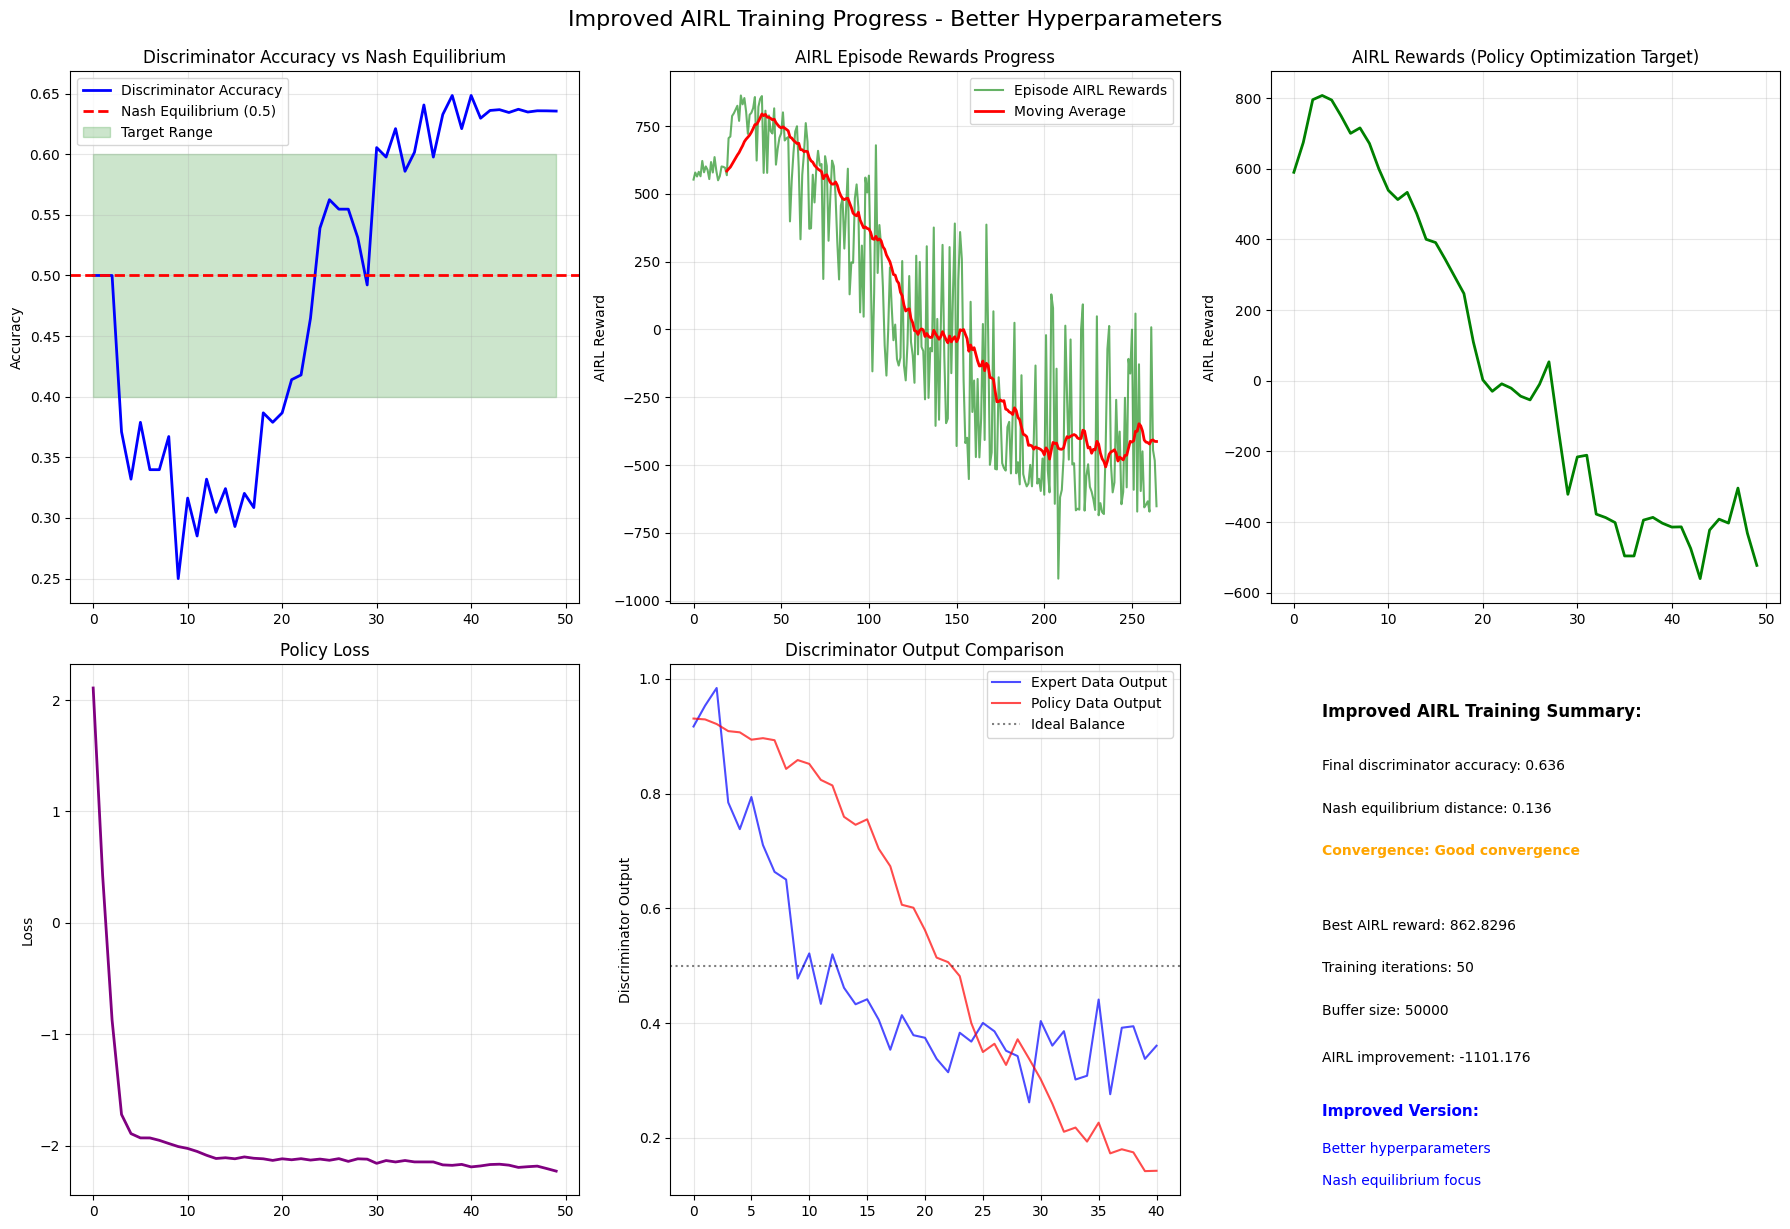


VARIABLE IMPEDANCE LEARNING ASSESSMENT - CORRECTED
Testing policy on 1000 expert state samples...

Actual Policy Impedance Parameter Assessment:
Based on deterministic policy actions on expert state distribution
  K1: [273, 991] N/m, mean=828, std=242, range=718
  K2: [276, 991] N/m, mean=824, std=241, range=716
  K3: [464, 995] N/m, mean=868, std=177, range=531
  K4: [84, 396] N/m, mean=324, std=105, range=312
  K5: [87, 396] N/m, mean=327, std=108, range=309
  K6: [83, 396] N/m, mean=325, std=108, range=313

  Overall Stiffness Range: [83, 995] N/m
  Overall Mean: 583 N/m
  Overall Std: 311 N/m
  Total Range: 912 N/m

  Damping coefficient: [0.108, 4.545], mean=1.245, std=1.421, range=4.437

  Expert Reference:
    Expert Stiffness Range: [79, 1000] N/m
    Expert Damping Range: [0.100, 4.597]

  Coverage Assessment:
    Stiffness range coverage: 99.0%
    Damping range coverage: 98.7%

  Variable Impedance Learning Quality: EXCELLENT
    K1 action space utilization: 194.4%
    K2 a

In [14]:
print("Launching AIRL Variable Impedance Learning with Corrected Assessment")
print("Environment reward = 0 (constant), only AIRL rewards matter")
print()
main()